## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import tree

df = pd.read_csv('housing.csv')

df_num = df.select_dtypes(include=['number']).dropna()

X = df_num.drop('median_house_value', axis=1)
y = df_num['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

In [2]:
regr_inicial = DecisionTreeRegressor(random_state=42)

regr_inicial.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

In [3]:
path = regr_inicial.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

In [4]:
arvores = []

for alpha in ccp_alphas[:40]:

    modelo = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )

    modelo.fit(X_train, y_train)

    arvores.append(modelo)

print(len(arvores))

40


### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [5]:

mse_treino = []
mse_teste = []

for arvore in arvores:

    pred_train = arvore.predict(X_train)
    pred_test = arvore.predict(X_test)

    mse_treino.append(
        mean_squared_error(y_train, pred_train)
    )

    mse_teste.append(
        mean_squared_error(y_test, pred_test)
    )

print("MSE calculado para todas as árvores.")

MSE calculado para todas as árvores.


### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

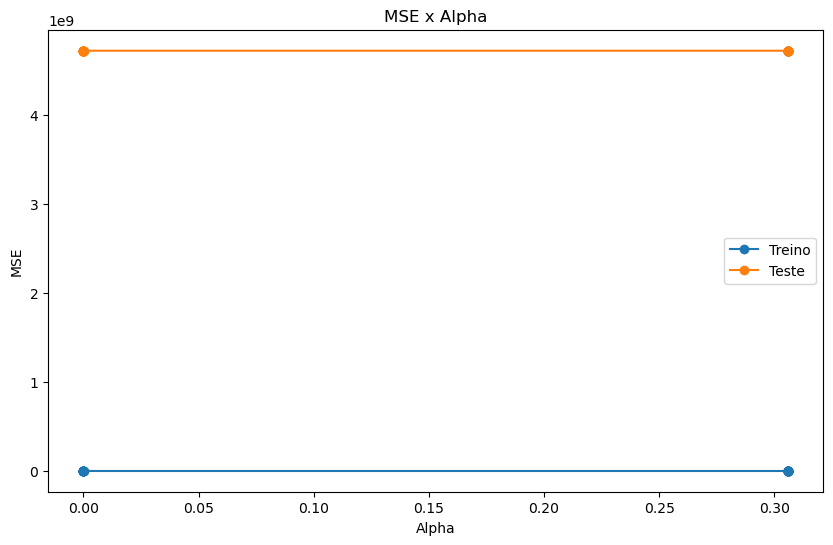

In [6]:
alphas_usados = ccp_alphas[:40]

plt.figure(figsize=(10,6))

plt.plot(alphas_usados, mse_treino, marker='o', label='Treino')
plt.plot(alphas_usados, mse_teste, marker='o', label='Teste')

plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE x Alpha')

plt.legend()

plt.show()

### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [7]:
indice_melhor = mse_teste.index(min(mse_teste))

melhor_alpha = ccp_alphas[:40][indice_melhor]

print("Melhor alpha:", melhor_alpha)
print("Menor MSE:", mse_teste[indice_melhor])

Melhor alpha: 0.30588523186100575
Menor MSE: 4723807200.102077


### 7. Visualize esta árvore.

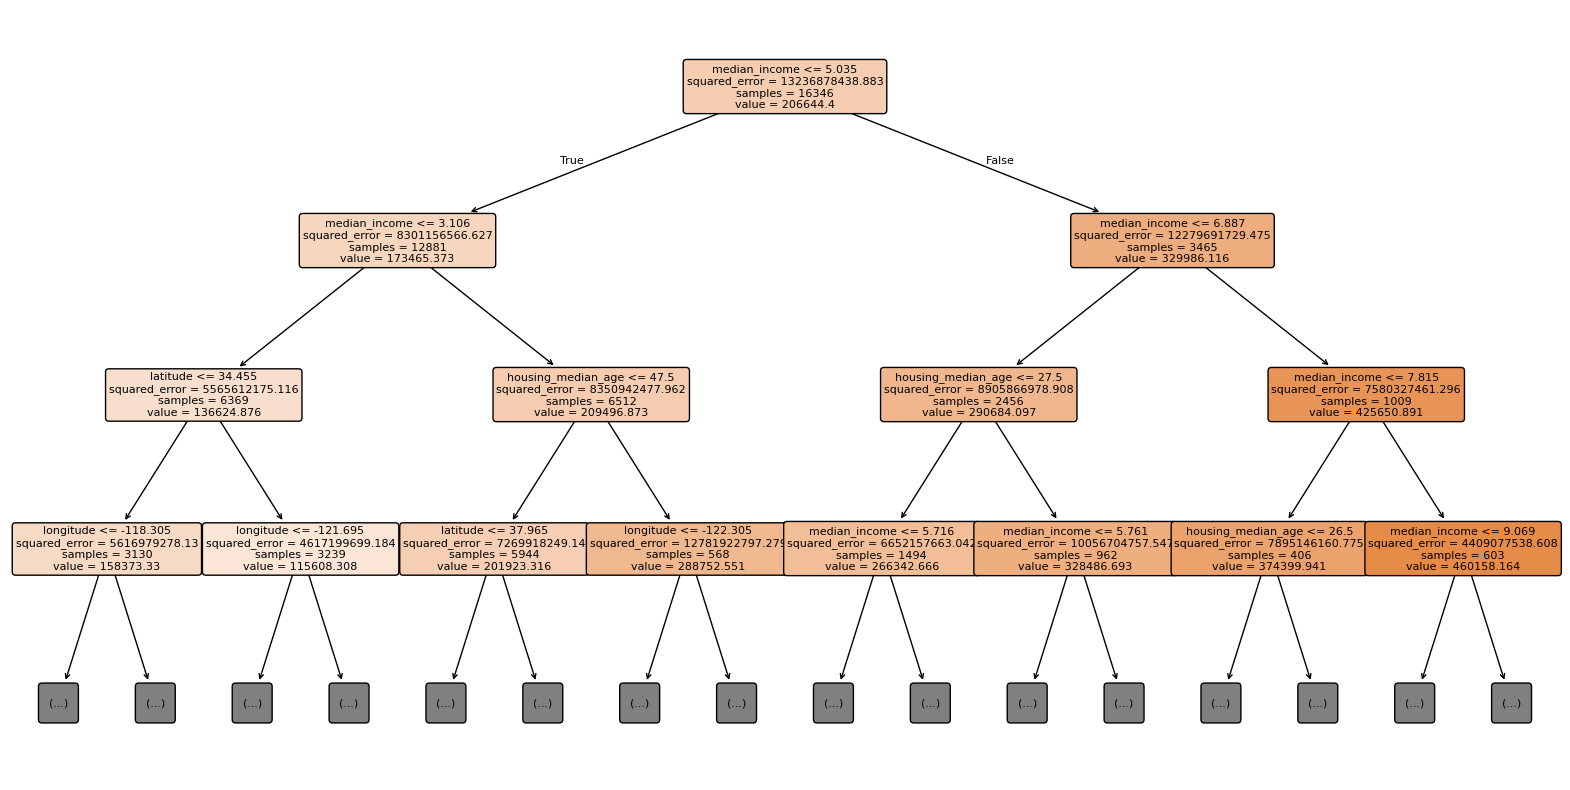

In [9]:
melhor_arvore = arvores[indice_melhor]

plt.figure(figsize=(20,10))

tree.plot_tree(
    melhor_arvore,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.show()